Loading Dataset
Training Shape : (82332, 45)
Testing Shape  : (175341, 45)
Combined Shape : (257673, 45)

First Five Rows
   id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0   1  0.000011   udp       -   INT      2      0     496       0   
1   2  0.000008   udp       -   INT      2      0    1762       0   
2   3  0.000005   udp       -   INT      2      0    1068       0   
3   4  0.000006   udp       -   INT      2      0     900       0   
4   5  0.000010   udp       -   INT      2      0    2126       0   

          rate  ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  \
0   90909.0902  ...                 1               2             0   
1  125000.0003  ...                 1               2             0   
2  200000.0051  ...                 1               3             0   
3  166666.6608  ...                 1               3             0   
4  100000.0025  ...                 1               3             0   

   ct_ftp_cmd  ct_flw_http_mthd  ct_

<Figure size 1000x800 with 0 Axes>

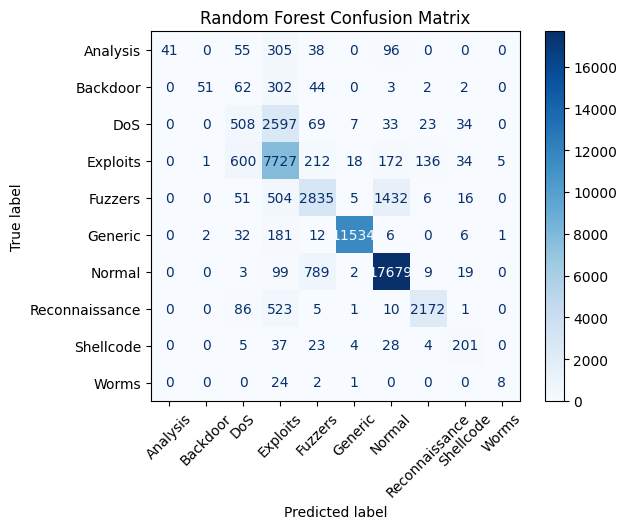


Top 20 Important Features

             Feature  Importance
6             sbytes    0.075950
26             smean    0.071291
35    ct_dst_src_ltm    0.064192
9               sttl    0.061785
34  ct_dst_sport_ltm    0.060238
40        ct_srv_dst    0.058396
33  ct_src_dport_ltm    0.056156
2            service    0.049489
30        ct_srv_src    0.042698
31      ct_state_ttl    0.042267
11             sload    0.034387
12             dload    0.029385
32        ct_dst_ltm    0.026562
7             dbytes    0.026134
10              dttl    0.026079
0                dur    0.025205
27             dmean    0.024673
8               rate    0.022312
1              proto    0.018887
23            tcprtt    0.017517


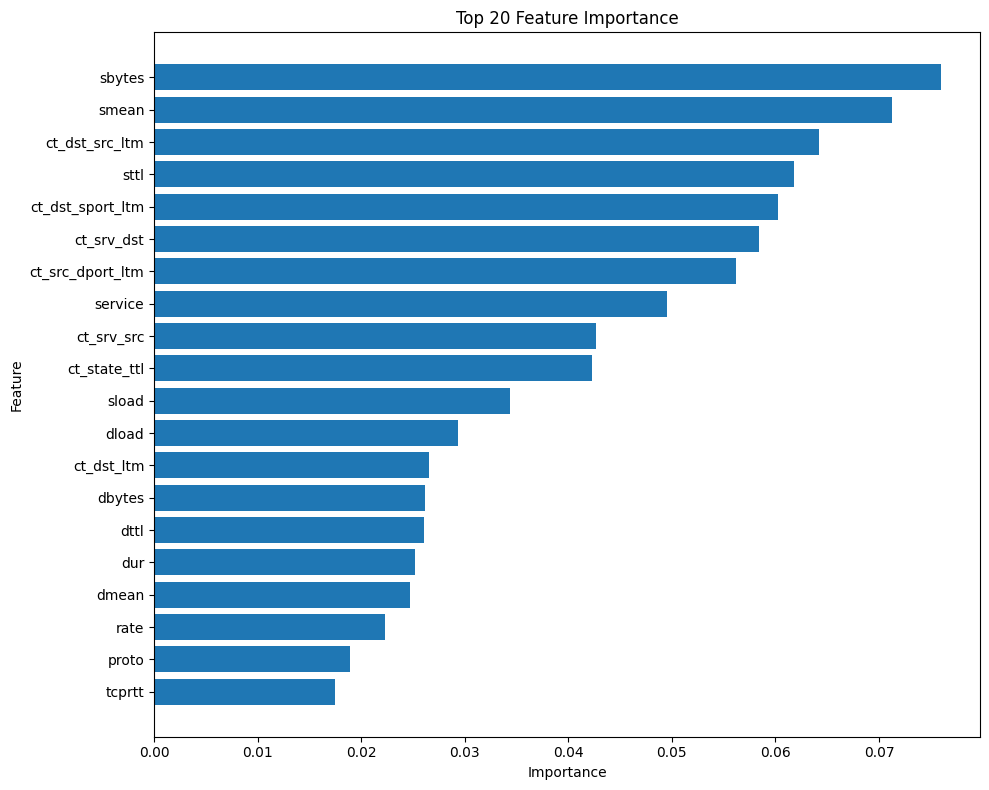

In [1]:
# ==========================================================
# Random Forest Classification on UNSW-NB15 Dataset
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================================================
# STEP 1 : LOAD DATASET
# ==========================================================

print("=" * 60)
print("Loading Dataset")
print("=" * 60)

train = pd.read_csv("UNSW_NB15_training-set.csv")
test = pd.read_csv("UNSW_NB15_testing-set.csv")

print("Training Shape :", train.shape)
print("Testing Shape  :", test.shape)

# Combine training and testing datasets
df = pd.concat([train, test], ignore_index=True)

print("Combined Shape :", df.shape)

# ==========================================================
# STEP 2 : DATA INFORMATION
# ==========================================================

print("\nFirst Five Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# ==========================================================
# STEP 3 : DATA CLEANING
# ==========================================================

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.drop_duplicates(inplace=True)

df["attack_cat"] = df["attack_cat"].fillna("Normal")

df.dropna(inplace=True)

print("\nShape After Cleaning :", df.shape)

# ==========================================================
# STEP 4 : ENCODE CATEGORICAL FEATURES
# ==========================================================

categorical_columns = ["proto", "service", "state"]

encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# Encode Target Column
target_encoder = LabelEncoder()
df["attack_cat"] = target_encoder.fit_transform(df["attack_cat"])

# ==========================================================
# STEP 5 : SELECT FEATURES
# ==========================================================

X = df.drop(["attack_cat", "label", "id"], axis=1, errors="ignore")

y = df["attack_cat"]

print("\nFeature Matrix :", X.shape)
print("Target Vector  :", y.shape)

# ==========================================================
# STEP 6 : TRAIN TEST SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

# ==========================================================
# STEP 7 : BUILD RANDOM FOREST MODEL
# ==========================================================

print("\nTraining Random Forest Model...\n")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ==========================================================
# STEP 8 : PREDICTION
# ==========================================================

y_pred = rf.predict(X_test)

# ==========================================================
# STEP 9 : MODEL EVALUATION
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# ==========================================================
# STEP 10 : CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

plt.figure(figsize=(10,8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Random Forest Confusion Matrix")
plt.show()

# ==========================================================
# STEP 11 : FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 Important Features\n")
print(importance.head(20))

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20],
    importance["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importance")

plt.tight_layout()
plt.show()

# ==========================================================
# STEP 12 : SAVE FEATURE IMPORTANCE
# ==========================================================

importance.to_csv(
    "RandomForest_FeatureImportance.csv",
    index=False
)



In [4]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [5]:
y_pred = rf.predict(X_test)

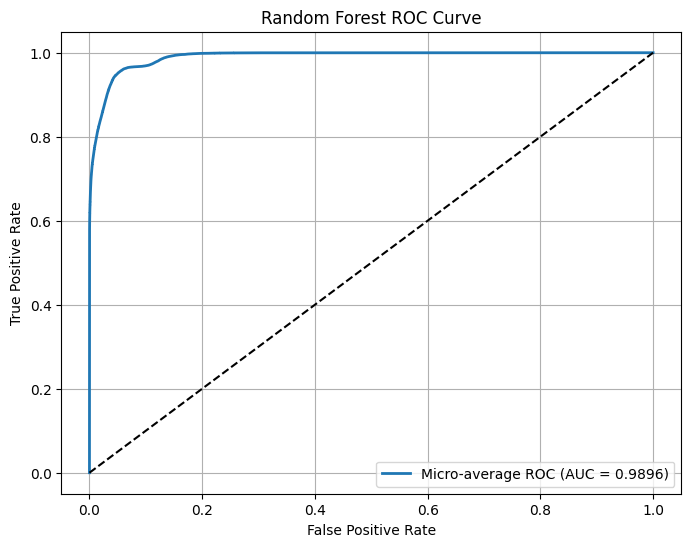

In [6]:
# ==========================================================
# ROC CURVE
# ==========================================================

# Predict probabilities
y_score = rf.predict_proba(X_test)

# Binarize the output labels
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# Calculate ROC and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC Curve
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin.ravel(),
    y_score.ravel()
)

roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="Micro-average ROC (AUC = %0.4f)" % roc_auc["micro"],
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend(loc="lower right")

plt.grid()

plt.show()

Loading Dataset
Training Shape : (82332, 45)
Testing Shape  : (175341, 45)
Combined Shape : (257673, 45)

First Five Rows
   id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0   1  0.000011   udp       -   INT      2      0     496       0   
1   2  0.000008   udp       -   INT      2      0    1762       0   
2   3  0.000005   udp       -   INT      2      0    1068       0   
3   4  0.000006   udp       -   INT      2      0     900       0   
4   5  0.000010   udp       -   INT      2      0    2126       0   

          rate  ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  \
0   90909.0902  ...                 1               2             0   
1  125000.0003  ...                 1               2             0   
2  200000.0051  ...                 1               3             0   
3  166666.6608  ...                 1               3             0   
4  100000.0025  ...                 1               3             0   

   ct_ftp_cmd  ct_flw_http_mthd  ct_

<Figure size 1000x800 with 0 Axes>

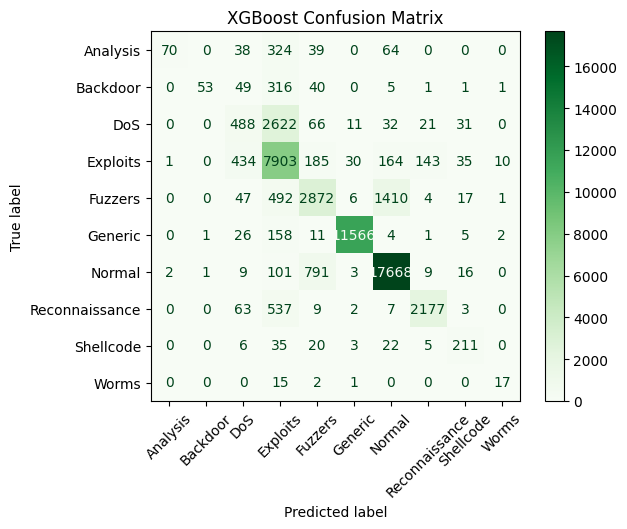


Top 20 Important Features

             Feature  Importance
9               sttl    0.202744
10              dttl    0.193345
19              swin    0.113204
34  ct_dst_sport_ltm    0.083570
31      ct_state_ttl    0.070665
41   is_sm_ips_ports    0.060977
2            service    0.037001
6             sbytes    0.033149
40        ct_srv_dst    0.026349
27             dmean    0.019195
26             smean    0.018931
35    ct_dst_src_ltm    0.015195
7             dbytes    0.013576
1              proto    0.010834
3              state    0.009375
33  ct_src_dport_ltm    0.008297
24            synack    0.007778
13             sloss    0.006534
14             dloss    0.005553
30        ct_srv_src    0.005535


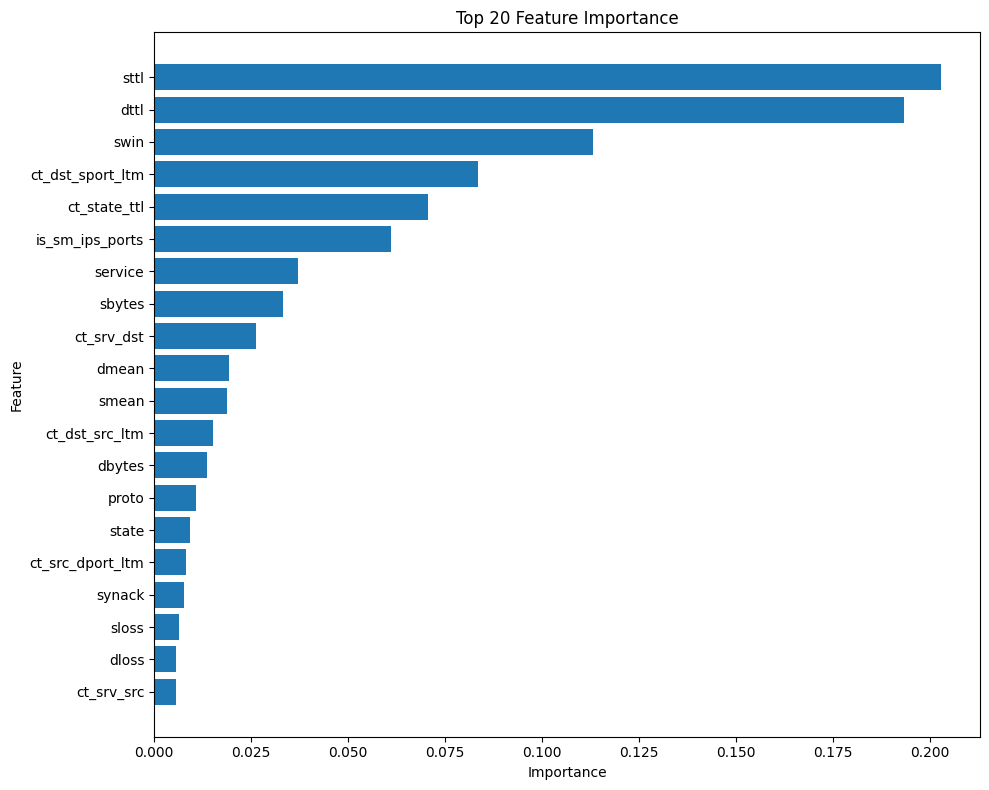

In [3]:
# ==========================================================
# XGBoost Classification on UNSW-NB15 Dataset
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

# ==========================================================
# STEP 1 : LOAD DATASET
# ==========================================================

print("=" * 60)
print("Loading Dataset")
print("=" * 60)

train = pd.read_csv("UNSW_NB15_training-set.csv")
test = pd.read_csv("UNSW_NB15_testing-set.csv")

print("Training Shape :", train.shape)
print("Testing Shape  :", test.shape)

df = pd.concat([train, test], ignore_index=True)

print("Combined Shape :", df.shape)

# ==========================================================
# STEP 2 : DATA INFORMATION
# ==========================================================

print("\nFirst Five Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# ==========================================================
# STEP 3 : DATA CLEANING
# ==========================================================

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.drop_duplicates(inplace=True)

df["attack_cat"] = df["attack_cat"].fillna("Normal")

df.dropna(inplace=True)

print("\nShape After Cleaning :", df.shape)

# ==========================================================
# STEP 4 : ENCODE CATEGORICAL FEATURES
# ==========================================================

categorical_columns = ["proto", "service", "state"]

encoders = {}

for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    encoders[col] = le

# Encode Target

target_encoder = LabelEncoder()

df["attack_cat"] = target_encoder.fit_transform(df["attack_cat"])

# ==========================================================
# STEP 5 : FEATURE SELECTION
# ==========================================================

X = df.drop(["attack_cat", "label", "id"], axis=1, errors="ignore")

y = df["attack_cat"]

print("\nFeature Matrix :", X.shape)
print("Target Vector  :", y.shape)

# ==========================================================
# STEP 6 : TRAIN TEST SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y

)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

# ==========================================================
# STEP 7 : BUILD XGBOOST MODEL
# ==========================================================

print("\nTraining XGBoost Model...\n")

xgb = XGBClassifier(

    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1

)

xgb.fit(X_train, y_train)

# ==========================================================
# STEP 8 : PREDICTION
# ==========================================================

y_pred = xgb.predict(X_test)

# ==========================================================
# STEP 9 : MODEL EVALUATION
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("=" * 60)
print("XGBOOST RESULTS")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

# ==========================================================
# STEP 10 : CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

plt.figure(figsize=(10,8))

disp.plot(
    cmap="Greens",
    xticks_rotation=45
)

plt.title("XGBoost Confusion Matrix")

plt.show()

# ==========================================================
# STEP 11 : FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 Important Features\n")

print(importance.head(20))

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20],
    importance["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 20 Feature Importance")

plt.tight_layout()

plt.show()

# ==========================================================
# STEP 12 : SAVE FEATURE IMPORTANCE
# ==========================================================

importance.to_csv(
    "XGBoost_FeatureImportance.csv",
    index=False
)



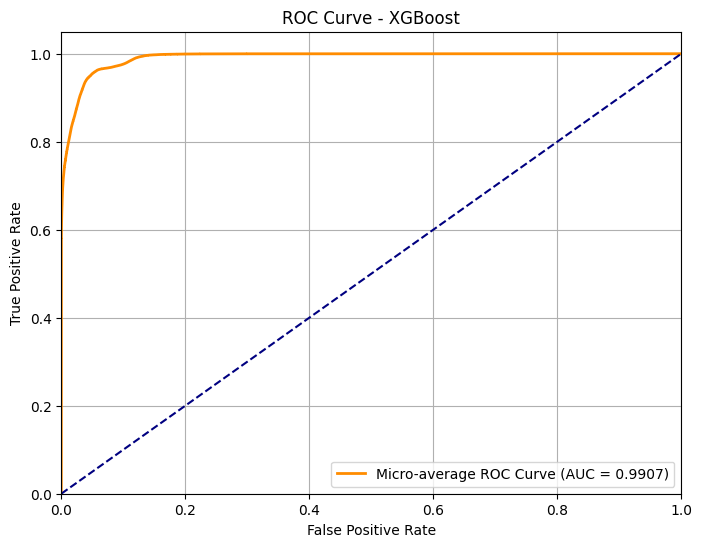

In [7]:
# ==========================================================
# ROC CURVE - XGBOOST
# ==========================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Predict probabilities
y_score = xgb.predict_proba(X_test)

# Convert labels to binary format
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# Calculate ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin.ravel(),
    y_score.ravel()
)

roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr["micro"],
    tpr["micro"],
    color="darkorange",
    linewidth=2,
    label="Micro-average ROC Curve (AUC = %0.4f)" % roc_auc["micro"]
)

plt.plot([0,1], [0,1], linestyle="--", color="navy")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# -----------------------------
# Random Forest Metrics
# -----------------------------
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='weighted')
rf_recall = recall_score(y_test, rf_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')
rf_auc = roc_auc_score(y_test, rf_prob, multi_class='ovr')

# -----------------------------
# XGBoost Metrics
# -----------------------------
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, average='weighted')
xgb_recall = recall_score(y_test, xgb_pred, average='weighted')
xgb_f1 = f1_score(y_test, xgb_pred, average='weighted')
xgb_auc = roc_auc_score(y_test, xgb_prob, multi_class='ovr')

# -----------------------------
# Comparison Table
# -----------------------------
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ],
    "XGBoost": [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        xgb_auc
    ]
})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")
print(comparison)




MODEL COMPARISON
      Metric  Random Forest   XGBoost
0   Accuracy       0.829650  0.834870
1  Precision       0.826598  0.832344
2     Recall       0.829650  0.834870
3   F1-Score       0.813981  0.818496
4    ROC-AUC       0.962938  0.968314


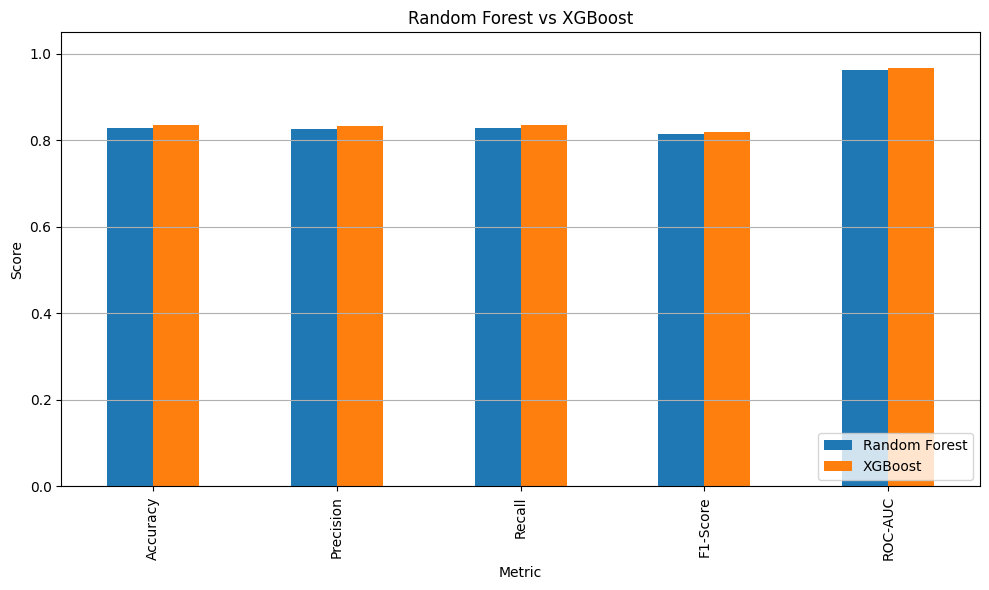

In [10]:
import matplotlib.pyplot as plt

comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Random Forest vs XGBoost")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis='y')
plt.legend(loc='lower right')

plt.tight_layout()
plt.savefig("Model_Comparison.png", dpi=300)
plt.show()